# Homework 6

## Author: Pablo Leyva

### HW6-1: Principal Component Analysis

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import svds
from scipy.linalg import svd
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set matplotlib style (try multiple options for compatibility)
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('default')


## 1. Function to project X onto top k principal components using SVD


In [10]:
def pca_svd(X, k, center=True):

    # Center the data if requested
    if center:
        mean = np.mean(X, axis=0)
        X_centered = X - mean
    else:
        mean = np.zeros(X.shape[1])
        X_centered = X
    
    # Perform SVD
    U, s, Vt = svd(X_centered, full_matrices=False)
    
    # Extract top k components
    U_k = U[:, :k]
    s_k = s[:k]
    Vt_k = Vt[:k, :]
    
    # Project data onto principal components
    X_projected = U_k @ np.diag(s_k)  # Or equivalently: X_centered @ Vt_k.T
    
    return X_projected, Vt_k, s_k, mean


## 2. Modified function using scipy.sparse.linalg.svds


In [11]:
def pca_svds(X, k, center=True):

    # Center the data if requested
    if center:
        mean = np.mean(X, axis=0)
        X_centered = X - mean
    else:
        mean = np.zeros(X.shape[1])
        X_centered = X
    
    # Ensure k is valid
    k = min(k, min(X_centered.shape) - 1)
    
    # Perform truncated SVD using sparse.linalg.svds
    # Note: svds returns singular values in descending order
    U, s, Vt = svds(X_centered, k=k)
    
    # svds returns singular values in ascending order, so reverse
    U = U[:, ::-1]
    s = s[::-1]
    Vt = Vt[::-1, :]
    
    # Project data onto principal components
    X_projected = U @ np.diag(s)  # Or equivalently: X_centered @ Vt.T
    
    return X_projected, Vt, s, mean


## 3. Condition number relationship

The condition number of $X^T X$ in terms of the condition number of $X$:

If $X = U \Sigma V^T$ is the SVD of $X$, then $X^T X = V \Sigma^2 V^T$.

The condition number of $X$ is:
$$\kappa(X) = \frac{\sigma_{\max}}{\sigma_{\min}}$$

The condition number of $X^T X$ is:
$$\kappa(X^T X) = \frac{\lambda_{\max}}{\lambda_{\min}} = \frac{\sigma_{\max}^2}{\sigma_{\min}^2} = \left(\frac{\sigma_{\max}}{\sigma_{\min}}\right)^2 = \kappa(X)^2$$

**Answer: $\kappa(X^T X) = \kappa(X)^2$**


## 4. Generate data and plot singular values


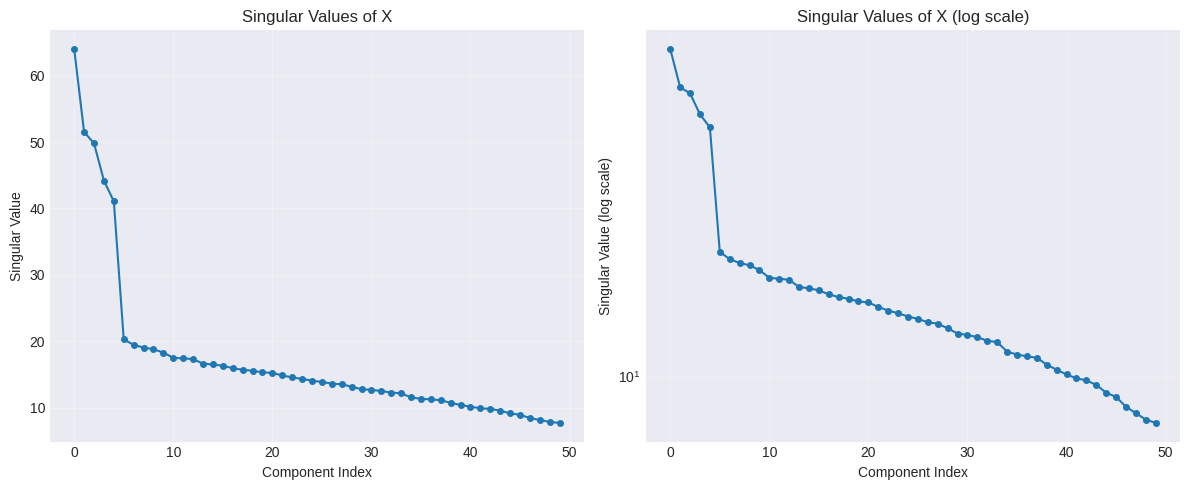

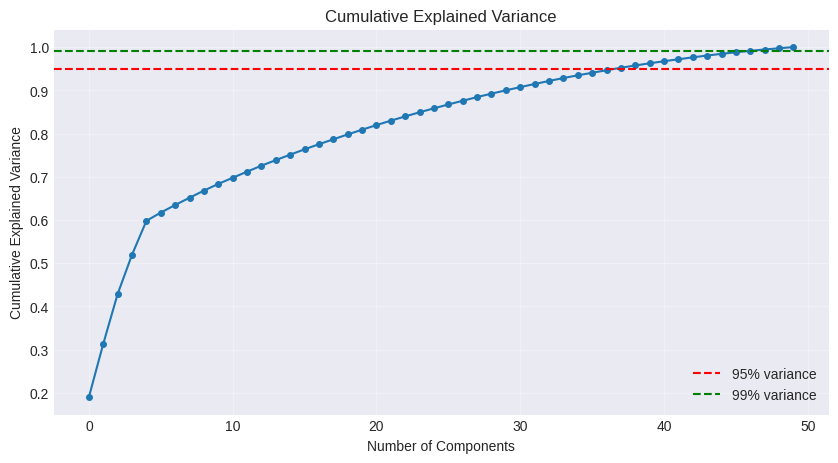

Number of components needed for 95% variance: 38
Number of components needed for 99% variance: 47


In [12]:
# Generate synthetic data
n_samples = 200
n_features = 50

# Create a matrix with some structure
# We'll create data with a few dominant directions
X = np.random.randn(n_samples, n_features)
# Add some structure by making some directions more important
for i in range(5):
    X += 0.5 * np.random.randn(n_samples, 1) @ np.random.randn(1, n_features)

# Compute SVD to get singular values
U, s, Vt = svd(X - np.mean(X, axis=0), full_matrices=False)

# Plot singular values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(s, 'o-', markersize=4)
plt.xlabel('Component Index')
plt.ylabel('Singular Value')
plt.title('Singular Values of X')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(s, 'o-', markersize=4)
plt.xlabel('Component Index')
plt.ylabel('Singular Value (log scale)')
plt.title('Singular Values of X (log scale)')
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compute cumulative explained variance
cumulative_variance = np.cumsum(s**2) / np.sum(s**2)

plt.figure(figsize=(10, 5))
plt.plot(cumulative_variance, 'o-', markersize=4)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.axhline(y=0.99, color='g', linestyle='--', label='99% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Number of components needed for 95% variance: {np.argmax(cumulative_variance >= 0.95) + 1}")
print(f"Number of components needed for 99% variance: {np.argmax(cumulative_variance >= 0.99) + 1}")


**How to decide how many principal components to use:**

1. **Scree plot (singular values plot)**: Look for an "elbow" where singular values drop off sharply
2. **Cumulative explained variance**: Choose k such that the top k components explain a desired percentage (e.g., 95% or 99%) of total variance
3. **Kaiser criterion**: Keep components with singular values > 1 (more appropriate for correlation matrices)
4. **Cross-validation**: Use domain knowledge or validation metrics to determine optimal k


## 5. Generate synthetic data with linear trend and perform PCA


In [13]:
# Generate synthetic data with a linear trend along a line
np.random.seed(42)
n_points = 100

# Create data along a line with some noise
# True direction vector
true_direction = np.array([1, 2])  # Direction of the line
true_direction = true_direction / np.linalg.norm(true_direction)  # Normalize

# Generate points along this line
t = np.linspace(-5, 5, n_points)
X_linear = np.outer(t, true_direction)

# Add some noise perpendicular to the line
noise_magnitude = 0.3
perpendicular = np.array([-true_direction[1], true_direction[0]])  # Perpendicular vector
noise = np.random.randn(n_points, 1) * noise_magnitude * perpendicular
X_linear = X_linear + noise

# Perform PCA
X_projected, components, s_values, mean = pca_svd(X_linear, k=2, center=True)

print(f"Principal components:\n{components}")
print(f"Singular values: {s_values}")
print(f"True direction: {true_direction}")
print(f"First PC direction: {components[0]}")
print(f"Angle between true direction and first PC: {np.arccos(np.abs(np.dot(true_direction, components[0])))*180/np.pi:.2f} degrees")


Principal components:
[[ 0.4434764   0.89628605]
 [-0.89628605  0.4434764 ]]
Singular values: [29.15789832  2.7081388 ]
True direction: [0.4472136  0.89442719]
First PC direction: [0.4434764  0.89628605]
Angle between true direction and first PC: 0.24 degrees


## 6. Plot original data, reconstructed data, and principal components


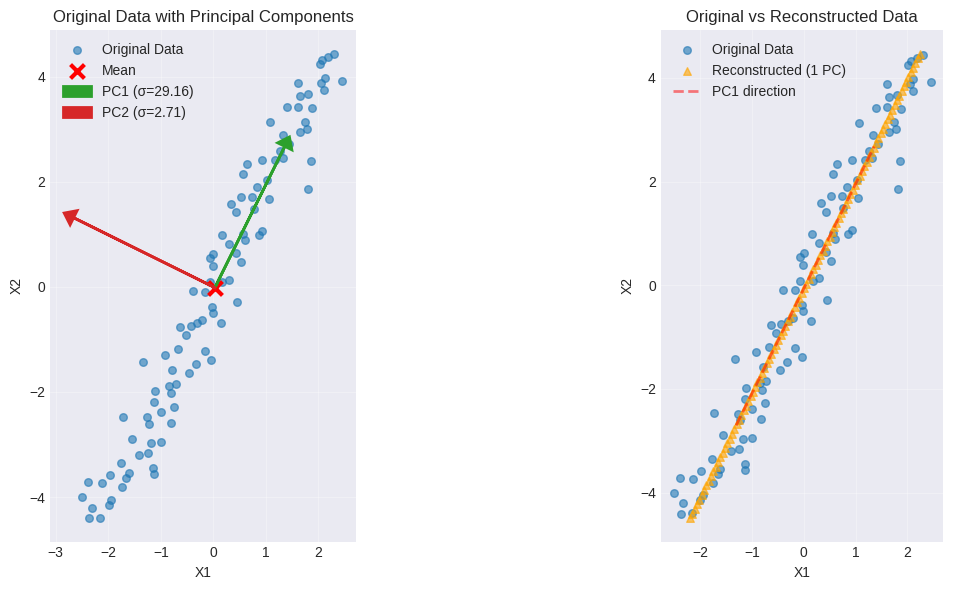

Mean squared reconstruction error (using 1 PC): 0.0733
Variance explained by first PC: 99.14%


In [14]:
# Reconstruct data using only the first principal component
X_reconstructed = X_projected[:, 0:1] @ components[0:1, :] + mean

# Plot everything
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Original data with principal components as vectors
ax = axes[0]
ax.scatter(X_linear[:, 0], X_linear[:, 1], alpha=0.6, label='Original Data', s=30)
ax.scatter(mean[0], mean[1], color='red', s=100, marker='x', linewidths=3, label='Mean')

# Plot principal components as vectors from the mean
scale = 3  # Scale for visualization
for i, (comp, s_val) in enumerate(zip(components, s_values)):
    ax.arrow(mean[0], mean[1], scale * comp[0], scale * comp[1], 
             head_width=0.3, head_length=0.2, fc=f'C{i+2}', ec=f'C{i+2}', 
             linewidth=2, label=f'PC{i+1} (σ={s_val:.2f})')

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_title('Original Data with Principal Components')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')

# Plot 2: Original vs Reconstructed
ax = axes[1]
ax.scatter(X_linear[:, 0], X_linear[:, 1], alpha=0.6, label='Original Data', s=30)
ax.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], alpha=0.6, 
           marker='^', label='Reconstructed (1 PC)', s=30, color='orange')

# Plot the principal component line
line_t = np.linspace(-scale, scale, 100)
line_points = mean + np.outer(line_t, components[0])
ax.plot(line_points[:, 0], line_points[:, 1], 'r--', alpha=0.5, linewidth=2, label='PC1 direction')

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_title('Original vs Reconstructed Data')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

# Calculate reconstruction error
reconstruction_error = np.mean(np.linalg.norm(X_linear - X_reconstructed, axis=1)**2)
print(f"Mean squared reconstruction error (using 1 PC): {reconstruction_error:.4f}")
print(f"Variance explained by first PC: {s_values[0]**2 / np.sum(s_values**2) * 100:.2f}%")


## 7. PCA without centering


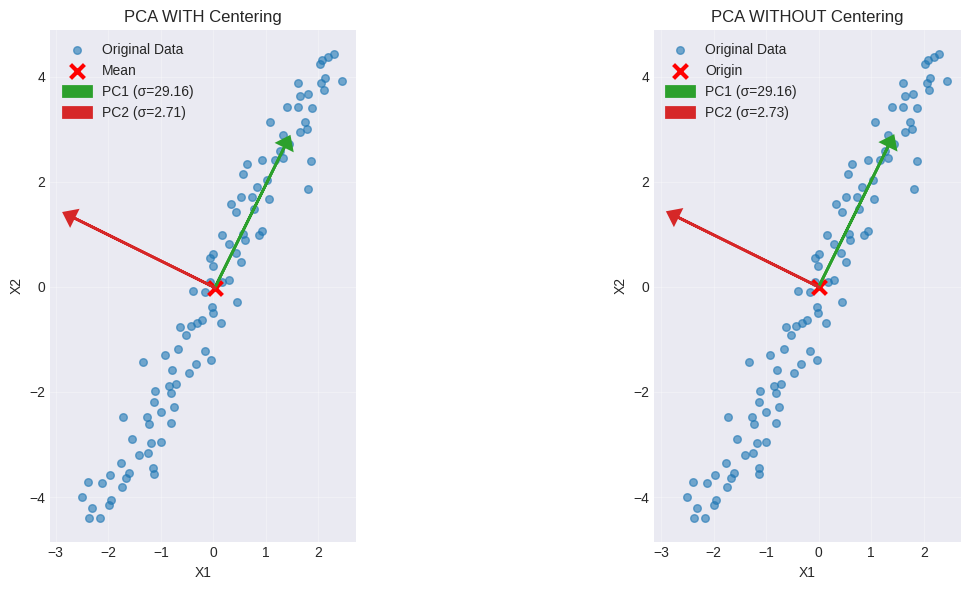

Comparison:
With centering - PC1 direction: [0.4434764  0.89628605]
Without centering - PC1 direction: [0.44347597 0.89628626]
Difference in directions (angle): 0.00 degrees

With centering - Singular values: [29.15789832  2.7081388 ]
Without centering - Singular values: [29.15789834  2.72599907]


In [15]:
# Perform PCA with and without centering
X_projected_centered, components_centered, s_centered, mean_centered = pca_svd(X_linear, k=2, center=True)
X_projected_not_centered, components_not_centered, s_not_centered, mean_not_centered = pca_svd(X_linear, k=2, center=False)

# Reconstruct both
X_recon_centered = X_projected_centered[:, 0:1] @ components_centered[0:1, :] + mean_centered
X_recon_not_centered = X_projected_not_centered[:, 0:1] @ components_not_centered[0:1, :] + mean_not_centered

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# With centering
ax = axes[0]
ax.scatter(X_linear[:, 0], X_linear[:, 1], alpha=0.6, label='Original Data', s=30)
ax.scatter(mean_centered[0], mean_centered[1], color='red', s=100, marker='x', linewidths=3, label='Mean')
scale = 3
for i, (comp, s_val) in enumerate(zip(components_centered, s_centered)):
    ax.arrow(mean_centered[0], mean_centered[1], scale * comp[0], scale * comp[1], 
             head_width=0.3, head_length=0.2, fc=f'C{i+2}', ec=f'C{i+2}', 
             linewidth=2, label=f'PC{i+1} (σ={s_val:.2f})')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_title('PCA WITH Centering')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')

# Without centering
ax = axes[1]
ax.scatter(X_linear[:, 0], X_linear[:, 1], alpha=0.6, label='Original Data', s=30)
ax.scatter(0, 0, color='red', s=100, marker='x', linewidths=3, label='Origin')
scale = 3
for i, (comp, s_val) in enumerate(zip(components_not_centered, s_not_centered)):
    ax.arrow(0, 0, scale * comp[0], scale * comp[1], 
             head_width=0.3, head_length=0.2, fc=f'C{i+2}', ec=f'C{i+2}', 
             linewidth=2, label=f'PC{i+1} (σ={s_val:.2f})')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_title('PCA WITHOUT Centering')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

print("Comparison:")
print(f"With centering - PC1 direction: {components_centered[0]}")
print(f"Without centering - PC1 direction: {components_not_centered[0]}")
print(f"Difference in directions (angle): {np.arccos(np.abs(np.dot(components_centered[0], components_not_centered[0])))*180/np.pi:.2f} degrees")
print(f"\nWith centering - Singular values: {s_centered}")
print(f"Without centering - Singular values: {s_not_centered}")


**Observations about centering:**

1. **With centering**: The first principal component captures the direction of maximum variance around the mean. This is the standard PCA approach.
2. **Without centering**: The first principal component is biased towards the direction from the origin to the data centroid. This can be misleading if the data is not centered around the origin.
3. **Effect**: Centering is crucial for PCA because we want to find directions of maximum variance, not directions influenced by the data's location in space.


## 8. Effect of a single outlier


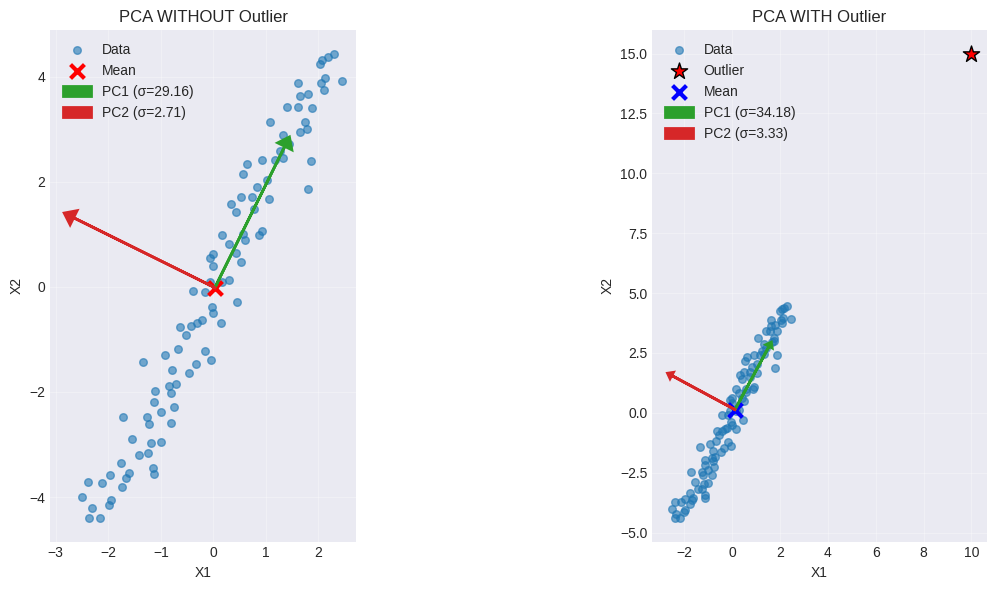

Comparison of Principal Components:
Without outlier - PC1 direction: [0.4434764  0.89628605]
With outlier - PC1 direction: [0.47448485 0.88026367]
Angle between PC1 directions: 2.00 degrees

Without outlier - Singular values: [29.15789832  2.7081388 ]
With outlier - Singular values: [34.17736652  3.32714012]

Without outlier - Mean: [ 0.02786494 -0.01393247]
With outlier - Mean: [0.12659896 0.13472032]
Shift in mean: 0.1785


In [16]:
# Add a single outlier
X_with_outlier = X_linear.copy()
outlier = np.array([[10, 15]])  # Far from the data
X_with_outlier = np.vstack([X_with_outlier, outlier])

# Perform PCA on both datasets
X_projected_clean, components_clean, s_clean, mean_clean = pca_svd(X_linear, k=2, center=True)
X_projected_outlier, components_outlier, s_outlier, mean_outlier = pca_svd(X_with_outlier, k=2, center=True)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Without outlier
ax = axes[0]
ax.scatter(X_linear[:, 0], X_linear[:, 1], alpha=0.6, label='Data', s=30)
ax.scatter(mean_clean[0], mean_clean[1], color='red', s=100, marker='x', linewidths=3, label='Mean')
scale = 3
for i, (comp, s_val) in enumerate(zip(components_clean, s_clean)):
    ax.arrow(mean_clean[0], mean_clean[1], scale * comp[0], scale * comp[1], 
             head_width=0.3, head_length=0.2, fc=f'C{i+2}', ec=f'C{i+2}', 
             linewidth=2, label=f'PC{i+1} (σ={s_val:.2f})')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_title('PCA WITHOUT Outlier')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')

# With outlier
ax = axes[1]
ax.scatter(X_with_outlier[:-1, 0], X_with_outlier[:-1, 1], alpha=0.6, label='Data', s=30)
ax.scatter(X_with_outlier[-1, 0], X_with_outlier[-1, 1], color='red', s=150, 
           marker='*', label='Outlier', edgecolors='black', linewidths=1)
ax.scatter(mean_outlier[0], mean_outlier[1], color='blue', s=100, marker='x', 
           linewidths=3, label='Mean')
scale = 3
for i, (comp, s_val) in enumerate(zip(components_outlier, s_outlier)):
    ax.arrow(mean_outlier[0], mean_outlier[1], scale * comp[0], scale * comp[1], 
             head_width=0.3, head_length=0.2, fc=f'C{i+2}', ec=f'C{i+2}', 
             linewidth=2, label=f'PC{i+1} (σ={s_val:.2f})')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_title('PCA WITH Outlier')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

# Quantitative comparison
print("Comparison of Principal Components:")
print(f"Without outlier - PC1 direction: {components_clean[0]}")
print(f"With outlier - PC1 direction: {components_outlier[0]}")
print(f"Angle between PC1 directions: {np.arccos(np.abs(np.dot(components_clean[0], components_outlier[0])))*180/np.pi:.2f} degrees")
print(f"\nWithout outlier - Singular values: {s_clean}")
print(f"With outlier - Singular values: {s_outlier}")
print(f"\nWithout outlier - Mean: {mean_clean}")
print(f"With outlier - Mean: {mean_outlier}")
print(f"Shift in mean: {np.linalg.norm(mean_outlier - mean_clean):.4f}")


**Observations about outliers:**

1. **Effect on mean**: The outlier shifts the mean significantly, pulling it towards the outlier.
2. **Effect on principal components**: The first principal component is strongly influenced by the outlier, often pointing towards it. This can completely distort the principal components.
3. **Robustness**: Standard PCA is not robust to outliers. The L2-norm used in PCA is sensitive to outliers. For robust PCA, one might use:
   - L1-norm PCA (sparse PCA)
   - Robust PCA methods (RPCA)
   - Outlier detection and removal before PCA
   - Median-based centering instead of mean-based


## Summary

This homework explored Principal Component Analysis (PCA) using Singular Value Decomposition (SVD):

**Key Takeaways:**
- Centering is crucial for PCA to find directions of maximum variance
- PCA is sensitive to outliers
- The number of components can be chosen using scree plots or cumulative variance explained
- Sparse SVD methods are more efficient when only top k components are needed
